In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.gaussian_process.kernels import Matern
import torch
import torch.nn as nn
from torch import tensor as tt

import sys as sys
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
import netCDF4 as nc


I run Python 3.9.10. 

# Utility function:

In [2]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

norm = torch.distributions.Normal(0.0, 1.0)


# Minimal example for help with debugging

  1%|          | 1/100 [00:00<00:48,  2.05it/s]

Epoch 0: Loss = 0.5958093133152196, Theta Gradient = -8.4520666860044e-05, Theta = 30.0, a Gradient = 7.108748832251877e-05, a = 30.0


 51%|█████     | 51/100 [00:27<00:23,  2.12it/s]

Epoch 50: Loss = 0.5952807772835472, Theta Gradient = -1.121091486311343e-06, Theta = 59.26307678222656, a Gradient = 1.9232479644415434e-06, a = 41.2227897644043


100%|██████████| 20/20 [00:59<00:00,  2.98s/it]


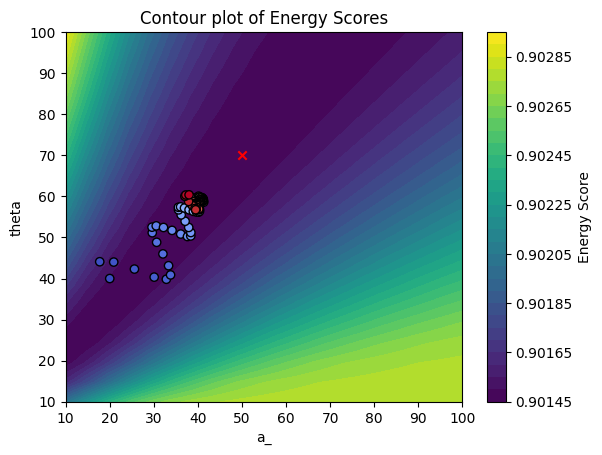

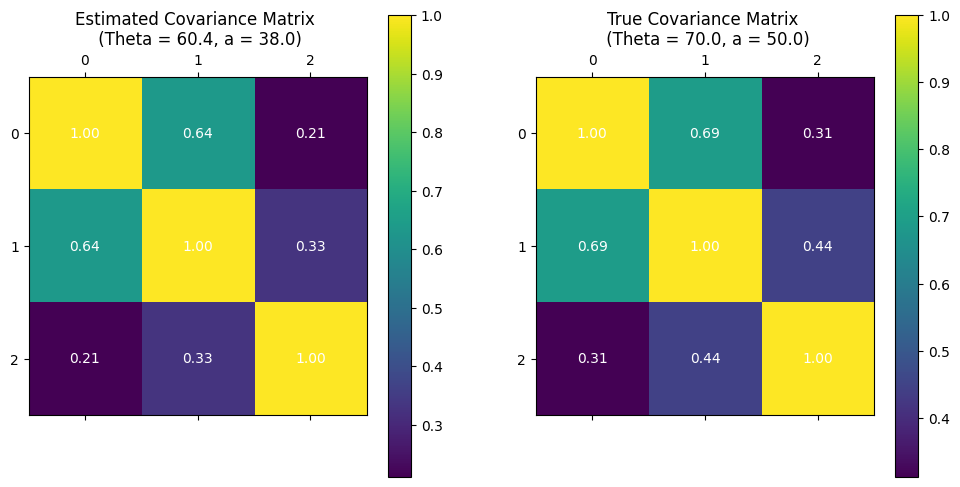

In [3]:
n_loc = 3

true_theta = tt(70., dtype=torch.float64)
true_a = tt(50., dtype=torch.float64)

# Define distance matrix -> covariance matrix -> observe from multivariate normal -> censor
locations = tt([[i * 10, i * 10] for i in range(n_loc)], dtype=torch.float64)
topo = torch.sin(locations.mean(dim=1)/30)**2 *4
dist_3d = torch.column_stack([locations, true_a * topo])
dist_matrix = torch.cdist(dist_3d, dist_3d)
true_cov = torch_Matern_05(dist_matrix, true_theta)

latent_z = sample_Gauss_fixed_noise(norm.sample((5000, true_cov.shape[0])).to(dtype=torch.float64), torch.linalg.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

# Observations
censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)


###
#Optimisation
###

SR_u = [] # keep track of SR values - theta, a, SR

fixed_noise = norm.sample((2000,latent_z.shape[1])).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta = tt(30.,requires_grad=True)
a_ = tt(30.,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta, a_], lr=10)
# comparing on the copula u-space
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([locations, a_ * topo])
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # construct current guess of the covariance matrix
    est_cov = torch_Matern_05(est_dist_matrix, theta)
    # sample from the current guess of the covariance matrix using Cholesky decomposition
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
    sims_u = norm.cdf(sims_z) # convert to U-space
    sims_u = torch.maximum(sims_u, censor_levels) # censor

    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 50 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}, a Gradient = {a_.grad.item()}, a = {a_.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),a_.item(),loss.item()])




# Plotting
SR_u_array = np.array(SR_u)
# Initialize the result array
theta_values = torch.linspace(10, 100, 20)
a_values = torch.linspace(10, 100, 20)
energy_scores = np.zeros((len(theta_values), len(a_values)))
# Compute the energy scores for each combination of theta and a_
for i, theta in enumerate(tqdm(theta_values)):
    for j, a_ in enumerate(a_values):
        estimated_dist_3d = torch.column_stack([locations, a_ * topo])
        est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
        est_cov = torch_Matern_05(est_dist_matrix, theta)
        chol_cov = torch.linalg.cholesky(est_cov)
        sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        sims_u = norm.cdf(sims_z)
        sims_u = torch.maximum(sims_u, censor_levels)
        loss = Energy_Score(0.5, copula_u_censored, sims_u)
        energy_scores[i, j] = loss.item()

# Create the contour plot
X, Y = np.meshgrid(a_values.numpy(), theta_values.numpy())
plt.contourf(X, Y, np.power(energy_scores, 1/5), cmap='viridis', levels=30)
plt.colorbar(label='Energy Score')
plt.xlabel('a_')
plt.ylabel('theta')
plt.title('Contour plot of Energy Scores')
SR_u_np = np.array(SR_u)
scatter = plt.scatter(SR_u_np[:, 1], SR_u_np[:, 0], c=np.arange(len(SR_u_np)), cmap='coolwarm', edgecolor='k')
plt.scatter(true_a, true_theta, c='red', marker='x',label='True Parameters')
plt.show()


estimated_dist_3d = torch.column_stack([locations, a_ * topo])
est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
est_cov = torch_Matern_05(est_dist_matrix, theta)
est_cov_np = est_cov.detach().numpy()
true_cov_np = true_cov.detach().numpy()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Plot the estimated covariance matrix
cax1 = ax1.matshow(est_cov_np, cmap='viridis')
fig.colorbar(cax1, ax=ax1)
ax1.set_title(f'Estimated Covariance Matrix \n (Theta = {SR_u[-1][0].__round__(1)}, a = {SR_u[-1][1].__round__(1)})')
# Add numbers over each cell
for (i, j), val in np.ndenumerate(est_cov_np):
    ax1.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
# Plot the true covariance matrix
cax2 = ax2.matshow(true_cov_np, cmap='viridis')
fig.colorbar(cax2, ax=ax2)
ax2.set_title(f'True Covariance Matrix \n (Theta = {true_theta.item()}, a = {true_a.item()})')
# Add numbers over each cell
for (i, j), val in np.ndenumerate(true_cov_np):
    ax2.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
plt.show()

# Real data

In [171]:
day_dates

[datetime.date(1999, 7, 1),
 datetime.date(1999, 7, 2),
 datetime.date(1999, 7, 3),
 datetime.date(1999, 7, 4),
 datetime.date(1999, 7, 5),
 datetime.date(1999, 7, 6),
 datetime.date(1999, 7, 7),
 datetime.date(1999, 7, 8),
 datetime.date(1999, 7, 9),
 datetime.date(1999, 7, 10),
 datetime.date(1999, 7, 11),
 datetime.date(1999, 7, 12),
 datetime.date(1999, 7, 13),
 datetime.date(1999, 7, 14),
 datetime.date(1999, 7, 15),
 datetime.date(1999, 7, 16),
 datetime.date(1999, 7, 17),
 datetime.date(1999, 7, 18),
 datetime.date(1999, 7, 19),
 datetime.date(1999, 7, 20),
 datetime.date(1999, 7, 21),
 datetime.date(1999, 7, 22),
 datetime.date(1999, 7, 23),
 datetime.date(1999, 7, 24),
 datetime.date(1999, 7, 25),
 datetime.date(1999, 7, 26),
 datetime.date(1999, 7, 27),
 datetime.date(1999, 7, 28),
 datetime.date(1999, 7, 29),
 datetime.date(1999, 7, 30),
 datetime.date(1999, 7, 31),
 datetime.date(1999, 8, 1),
 datetime.date(1999, 8, 2),
 datetime.date(1999, 8, 3),
 datetime.date(1999, 8, 4)

In [4]:
#################################################################### Loading GNM ####################################################################
sys.path.append('../')

import pickle


GNM_output = pickle.load( open("trainset_output_1999-07_2019-07.pkl","rb") )
#################################################################### Problematic locations? ###############################################################

location_keys = list(GNM_output.keys())                 # '([0, 16], [44, 60])', ...
output_keys = list(GNM_output[location_keys[0]].keys()) # 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'date', 5'pred_p', 6'mask', 7'idx_loc_in_region'

# May have to remove a location that doesn't have the correct number of days:
location_keys.remove(location_keys[344]) #to remove for gamma_20_20 train  
#################################################################### Utility functions ####################################################################
def give_lat_lon(location_key):
    return [ int(re.findall(r'\d+',string)[0]) for string in location_key.split(',')]

def is_loc_land(location,row,column):
    return GNM_output[location]['mask'][0][row][column]

#location_keys.remove('lat_50.95_49.35_lon_-4.55_-2.95') # 'lat_50.95_49.35_lon_-4.55_-2.95' has no data after week indexed 255, so I did not consider it.
day_dates = [pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date']]
output_keys.remove('idx_loc_in_region') # not usefull
output_keys.remove('date') # no more usefull

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

GNM_landonly = [] 
land_counter = -1
for location in tqdm(location_keys):
    for col in range(4):
        for row in range(4):
            if not is_loc_land(location,row,col):#check if land
               continue  
            land_counter+=1
            GNM_landonly.append([[],[],[],[],[]]) # parameters except location
            temp_lat_lon = give_lat_lon(location)
            GNM_landonly[land_counter].append([temp_lat_lon[1]-8+row,(temp_lat_lon[2])+6+col]) #location
            for param_idx,param in enumerate(output_keys[:-1]):
                for day in range(len(GNM_output[location_keys[0]]['pred_mu'])):
                    qqq = [location,param,day,row,col]
                    GNM_landonly[land_counter][param_idx].append(GNM_output[location][param][day][row,col])

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))

#################################################################### Elevation data ####################################################################
fn = 'topo_0.1_degree.nc'
ds = nc.Dataset(fn)
h = ds['Band1'][:]
h = np.flip(np.matrix(h),axis=0)
topo_dist = euclidean_distances(np.array([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1))

# load obs_norm_all and censor_levels_di
obs_norm_all = np.load('obs_norm_all_train.npy')
censor_levels_di = np.load('censor_levels_di_train.npy')
censor_levels_u = scs.norm.cdf(censor_levels_di)

100%|██████████| 344/344 [01:09<00:00,  4.96it/s]


## Simulated experiment

10


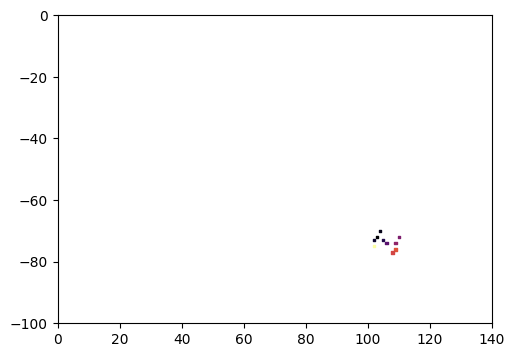

In [105]:
def generate_subsample_locs(locs_nb):
    locs=[]
    while len(locs)<locs_nb:
        #random_center = np.random.choice(range(len(GNM_landonly))) 
        random_center = 3532  
        locs = np.where([math.dist(GNM_landonly[k][5],GNM_landonly[random_center ][5])<(np.sqrt(locs_nb/np.pi)+3) for k in range(len(GNM_landonly))])[0]
    return np.random.choice(locs,size=locs_nb,replace=False)    

fig = plt.gcf() 
fig.set_size_inches(5.6,4)
locs = generate_subsample_locs(locs_nb=10)
print(len(locs))

plt.scatter([GNM_landonly[loc][5][1] for loc in locs],
[-GNM_landonly[loc][5][0] for loc in locs],
c=[GNM_landonly[loc][3][300] for loc in locs],
cmap='inferno_r',s=3,marker='s')

plt.xlim(0,140)
plt.ylim(-100,0)
plt.show()

In [131]:
estimated_cov.median()

tensor(0.7434, dtype=torch.float64, grad_fn=<MedianBackward0>)

In [139]:
fake_a_ = tt(-4.5)
fake_theta_ = 45.

sim_nb = 50

fixed_noise = norm.sample((sim_nb,len(locs))).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

#
# fake cov used as ground truth
#
fake_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
fake_a_.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)])[:len(locs), :len(locs)] # this part is for elevation
fake_dist_matrix = torch.cdist(fake_dist_3d, fake_dist_3d)
# construct the covariance matrix
fake_cov = torch_Matern_05(fake_dist_matrix, fake_theta_)
# sample
chol_cov_fake = torch.linalg.cholesky(fake_cov)
sims_z_fake = sample_Gauss_fixed_noise(fixed_noise[0], chol_cov_fake).unsqueeze(0) # on the Gaussian Z-space
#sims_u_fake = norm.cdf(sims_z_fake) # convert to U-space

#
# optimisation
#

# initialise params
theta_ = tt(30.,requires_grad=True)
a_ = tt(-1.,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta_, a_], lr=0.02)

for epoch in range(5000):
    optimizer.zero_grad()

    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
    a_.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)])[:len(locs), :len(locs)] # this part is for elevation
    estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta_)

    # sample
    chol_cov_est = torch.linalg.cholesky(estimated_cov)
    sims_z_est = sample_Gauss_fixed_noise(fixed_noise, chol_cov_est) # on the Gaussian Z-space
    #sims_u_est = norm.cdf(sims_z_est) # convert to U-space
    SR = Energy_Score(0.5, sims_z_fake, sims_z_est) 
    if estimated_cov.median() < 0.01:
        SR = SR + 1e-5* 1/estimated_cov.mean()
        print(epoch,'penalizing', 1e-2* 1/estimated_cov.mean().item())
    SR.backward()

    # Clip gradients
    torch.nn.utils.clip_grad_norm_([theta_, a_], max_norm=1e-2)

    if epoch % 50 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {SR.item()}, Theta Gradient = {theta_.grad.item()}, Theta = {theta_.item()}, a Gradient = {a_.grad.item()}, a = {a_.exp().item()}')

    optimizer.step()

estimated_cov, fake_cov

0 penalizing 0.07474940972750117
Epoch 0: Loss = 1.5876941660174506, Theta Gradient = -0.00033613169216550887, Theta = 30.0, a Gradient = 0.009993831627070904, a = 0.3678794503211975
1 penalizing 0.07423740608053075
2 penalizing 0.07371603014752041
3 penalizing 0.0731854136256467
4 penalizing 0.07264570982423772
5 penalizing 0.07209708867328962
6 penalizing 0.07153974328394863
7 penalizing 0.07097388477880215
8 penalizing 0.07039973838238282
9 penalizing 0.06981755320496257
10 penalizing 0.06922759605344654
11 penalizing 0.06863014216323558
12 penalizing 0.06802549007543048
13 penalizing 0.06741395608176054
14 penalizing 0.06679585786751915
15 penalizing 0.06617154082249192
16 penalizing 0.06554135800028973
17 penalizing 0.06490566801048105
18 penalizing 0.06426484673493393
19 penalizing 0.06361927597641238
20 penalizing 0.06296934530830545
Epoch 50: Loss = 1.5504916933378663, Theta Gradient = -0.00032280234154313803, Theta = 30.995065689086914, a Gradient = 0.009994600899517536, a = 0

(tensor([[1.0000, 0.9336, 0.9600, 0.8261, 0.8917, 0.8936, 0.7879, 0.6907, 0.8729,
          0.7311],
         [0.9336, 1.0000, 0.9260, 0.7855, 0.9545, 0.8671, 0.7539, 0.6585, 0.8575,
          0.7025],
         [0.9600, 0.9260, 1.0000, 0.8477, 0.8879, 0.9285, 0.8120, 0.7099, 0.9090,
          0.7550],
         [0.8261, 0.7855, 0.8477, 1.0000, 0.7553, 0.8972, 0.9478, 0.8362, 0.8852,
          0.8788],
         [0.8917, 0.9545, 0.8879, 0.7553, 1.0000, 0.8380, 0.7274, 0.6350, 0.8342,
          0.6798],
         [0.8936, 0.8671, 0.9285, 0.8972, 0.8380, 1.0000, 0.8680, 0.7576, 0.9687,
          0.8101],
         [0.7879, 0.7539, 0.8120, 0.9478, 0.7274, 0.8680, 1.0000, 0.8728, 0.8658,
          0.9265],
         [0.6907, 0.6585, 0.7099, 0.8362, 0.6350, 0.7576, 0.8728, 1.0000, 0.7570,
          0.9217],
         [0.8729, 0.8575, 0.9090, 0.8852, 0.8342, 0.9687, 0.8658, 0.7570, 1.0000,
          0.8138],
         [0.7311, 0.7025, 0.7550, 0.8788, 0.6798, 0.8101, 0.9265, 0.9217, 0.8138,
         

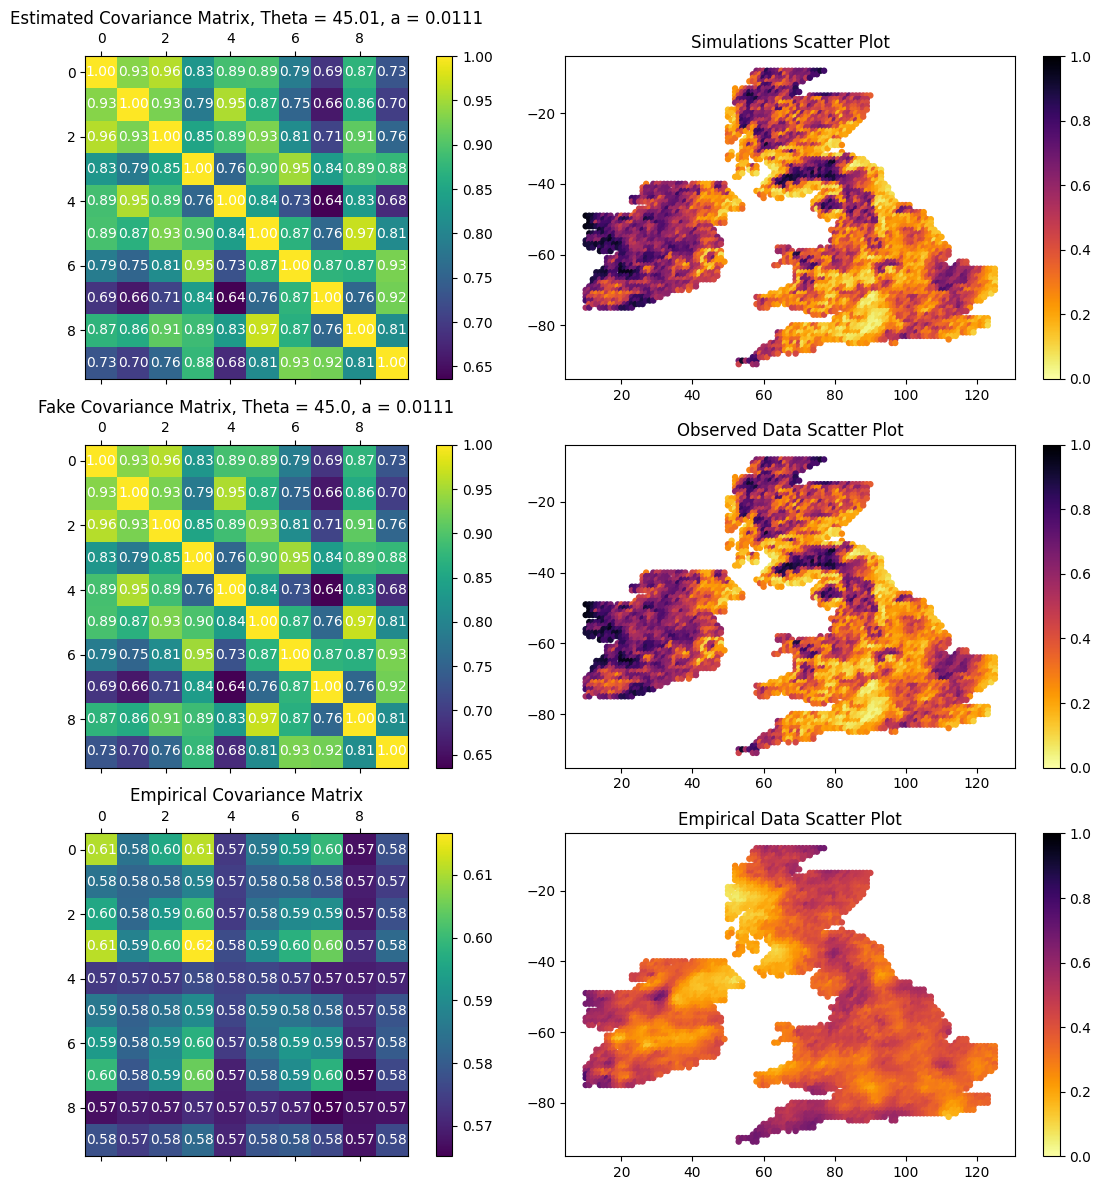

In [164]:
fixed_noise = norm.sample((1,len(GNM_landonly))).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

#
# estimated cov
#
estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
a_.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

# construct the covariance matrix
estimated_cov = torch_Matern_05(estimated_dist_matrix, theta_)
# sample
chol_cov = torch.linalg.cholesky(estimated_cov)
sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
sims_u = norm.cdf(sims_z) # convert to U-space

#
# fake cov used here as true
#
fake_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),
fake_a_.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)])
fake_dist_matrix = torch.cdist(fake_dist_3d, fake_dist_3d)
# construct current guess of the covariance matrix
fake_cov = torch_Matern_05(fake_dist_matrix, fake_theta_)
# sample
chol_cov_fake = torch.linalg.cholesky(fake_cov)
sims_z_fake = sample_Gauss_fixed_noise(fixed_noise, chol_cov_fake) # on the Gaussian Z-space
sims_u_fake = norm.cdf(sims_z_fake) # convert to U-space


loc_len = len(locs)


fig, axs = plt.subplots(3, 2, figsize=(12, 12))
# Plot estimated estimated matrix
est_cov_np = estimated_cov.detach().numpy()[:loc_len, :loc_len]
im1 = axs[0, 0].matshow(est_cov_np)
axs[0, 0].set_title(f'Estimated Covariance Matrix, Theta = {np.round(theta_.item(),2)}, a = {np.round(a_.exp().item(),4)}')
fig.colorbar(im1, ax=axs[0, 0])
# Add numbers over each cell
for (i, j), val in np.ndenumerate(est_cov_np):
    axs[0, 0].text(j, i, f'{val:.2f}', ha='center', va='center', color='white')

# Plot scatter plot of simulations
sc = axs[0, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                       [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                       c=sims_u.detach().numpy(), cmap='inferno_r', vmin=0, vmax=1, s=13)
axs[0, 1].set_title('Simulations Scatter Plot')
fig.colorbar(sc, ax=axs[0, 1])

# Plot observed covariance matrix
fake_cov_np = fake_cov.detach().numpy()[:loc_len, :loc_len]
im2 = axs[1, 0].matshow(fake_cov_np)
axs[1, 0].set_title(f'Fake Covariance Matrix, Theta = {np.round(fake_theta_,2)}, a = {np.round(fake_a_.exp().item(),4)}')
fig.colorbar(im2, ax=axs[1, 0])
# Add numbers over each cell
for (i, j), val in np.ndenumerate(fake_cov_np):
    axs[1, 0].text(j, i, f'{val:.2f}', ha='center', va='center', color='white')

# Plot observed data
sc_obs = axs[1, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                           [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                           c=sims_u_fake.detach().numpy(), cmap='inferno_r', vmin=0, vmax=1, s=13)
axs[1, 1].set_title('Observed Data Scatter Plot')
fig.colorbar(sc_obs, ax=axs[1, 1])

# Plot empirical covariance matrix
emp_cov_adjusted = (emp_cov_z+0.)/emp_cov_z.max()
im3 = axs[2, 0].matshow(emp_cov_adjusted.detach().numpy()[:loc_len, :loc_len])
axs[2, 0].set_title('Empirical Covariance Matrix')
fig.colorbar(im3, ax=axs[2, 0])
# Add numbers over each cell
for (i, j), val in np.ndenumerate(emp_cov_adjusted.detach().numpy()[:loc_len, :loc_len]):
    axs[2, 0].text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
# sample
chol_cov_emp = torch.linalg.cholesky(emp_cov_adjusted)
sims_z_emp = sample_Gauss_fixed_noise(fixed_noise, chol_cov_emp) # on the Gaussian Z-space
sims_u_emp = norm.cdf(sims_z_emp) # convert to U-space
# Plot empirical data
sc_emp = axs[2, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
                           [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
                           c=sims_u_emp.detach().numpy(), cmap='inferno_r', vmin=0, vmax=1, s=13)

axs[2, 1].set_title('Empirical Data Scatter Plot')
fig.colorbar(sc_emp, ax=axs[2, 1])
plt.tight_layout()
plt.show()


### Good initial values for $\theta, a$

In [30]:
emp_cov_z = np.cov(obs_norm_all.T)
emp_cov_z = tt(emp_cov_z, dtype=torch.float64)


In [87]:
# compute Frobenius norm for different theta and a
theta_values = torch.linspace(30, 55, 20)
a_values = torch.linspace(-8, -3, 40)

frobenius_norms = np.zeros((len(theta_values), len(a_values)))
mat_means = np.zeros((len(theta_values), len(a_values)))

for j,alpha in tqdm(enumerate(a_values)):
    for i,theta in enumerate(theta_values):
        estimated_dist_3d = torch.column_stack([
        tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
        alpha.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
        estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

        # construct the covariance matrix
        estimated_cov = torch_Matern_05(estimated_dist_matrix, theta)
        
        frobenius_norms[i,j] = torch.norm(estimated_cov - emp_cov_z, p='fro').item()
        mat_means[i,j] = torch.mean(estimated_cov).item()

40it [03:10,  4.77s/it]


In [84]:
estimated_dist_3d = torch.column_stack([
tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
tt(0).exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

# construct the covariance matrix
estimated_cov = torch_Matern_05(estimated_dist_matrix, tt(55.))

torch.norm(estimated_cov - emp_cov_z, p='fro').item()

1609.9531827433582

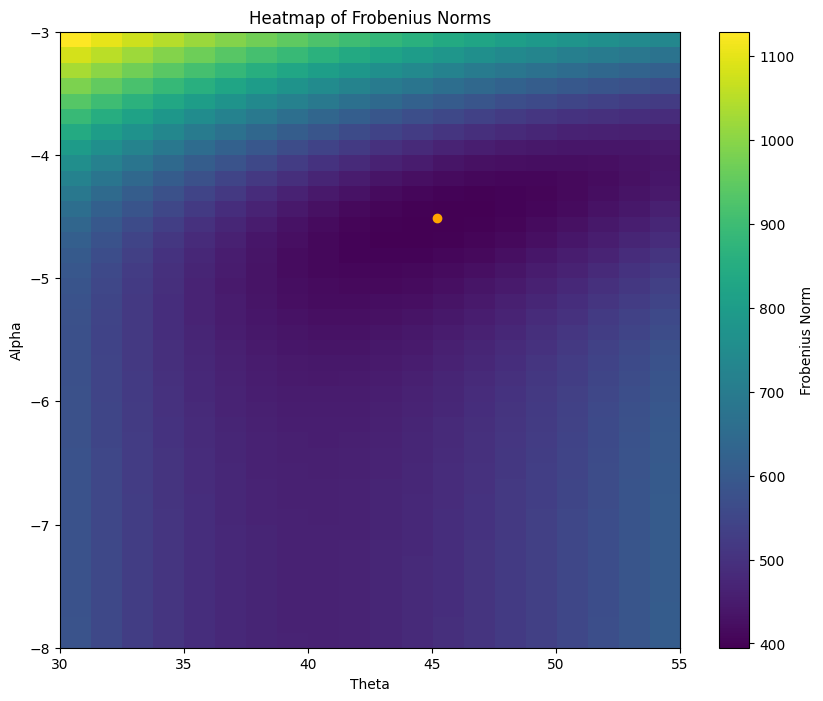

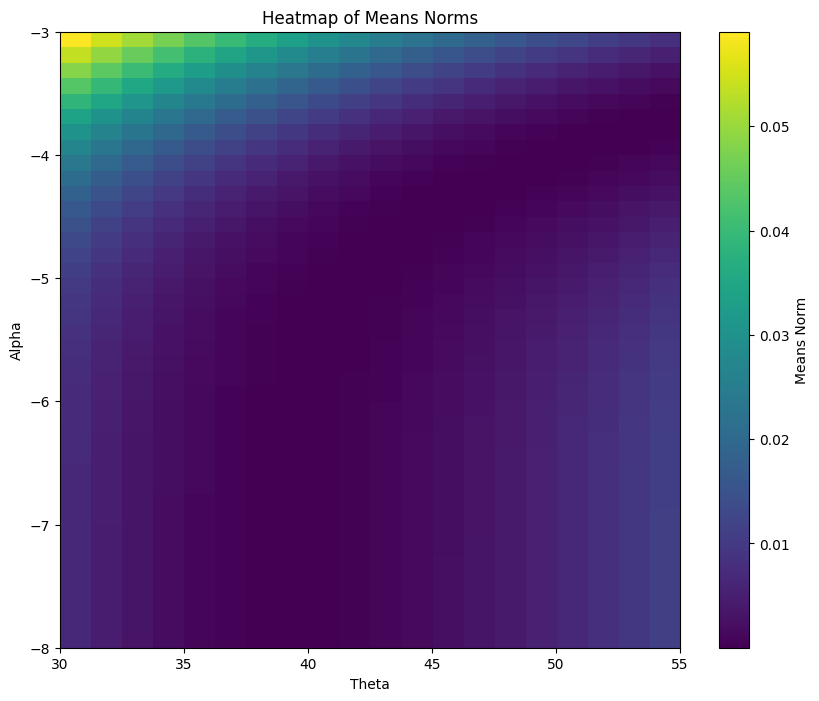

In [92]:
# Plot the heatmap of F-norm
plt.figure(figsize=(10, 8))
plt.imshow(frobenius_norms.T, aspect='auto', origin='lower', extent=[theta_values.min(), theta_values.max(), a_values.min(), a_values.max()])
plt.colorbar(label='Frobenius Norm')
plt.xlabel('Theta')
plt.ylabel('Alpha')
plt.title('Heatmap of Frobenius Norms')
plt.scatter(45.20140838623047,tt(0.01099279522895813).log(), c='orange')
plt.show()
# Plot the heatmapm of mat mean
plt.figure(figsize=(10, 8))
plt.imshow(((mat_means-(0.3859))**2).T, aspect='auto', origin='lower', extent=[theta_values.min(), theta_values.max(), a_values.min(), a_values.max()])
plt.colorbar(label='Means Norm')
plt.xlabel('Theta')
plt.ylabel('Alpha')
plt.title('Heatmap of Means Norms')
plt.show()

In [61]:
tt(-7.,requires_grad=True).exp()

tensor(0.0009, grad_fn=<ExpBackward0>)

In [64]:

theta = tt(40.,requires_grad=True)
alpha = tt(-7.,requires_grad=True)

optimizer = torch.optim.Adam([theta, alpha], lr=0.2)

for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
    alpha.exp()*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
    estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)

    # construct the covariance matrix
    estimated_cov = torch_Matern_05(estimated_dist_matrix, theta)
    
    loss = torch.norm(estimated_cov - emp_cov_z, p='fro')
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        print(f'Epoch {epoch}: Loss = {loss}, Theta = {theta.item()}, Alpha = {alpha.exp().item()}')
    

  1%|          | 1/100 [00:00<01:09,  1.42it/s]

Epoch 0: Loss = 463.5532701096762, Theta = 40.20000076293945, Alpha = 0.0011137749534100294


  2%|▏         | 2/100 [00:01<01:18,  1.24it/s]

Epoch 1: Loss = 462.3228651979051, Theta = 40.367977142333984, Alpha = 0.0013585783308371902


  3%|▎         | 3/100 [00:02<01:14,  1.31it/s]

...

Epoch 97: Loss = 394.5851487014879, Theta = 45.1953239440918, Alpha = 0.011017895303666592


 99%|█████████▉| 99/100 [01:09<00:00,  1.43it/s]

Epoch 98: Loss = 394.58495836083347, Theta = 45.19851303100586, Alpha = 0.011000026017427444


100%|██████████| 100/100 [01:09<00:00,  1.43it/s]

Epoch 99: Loss = 394.58591939027906, Theta = 45.20140838623047, Alpha = 0.01099279522895813


In [73]:
theta, alpha.exp(), alpha

(tensor(45.2014, requires_grad=True),
 tensor(0.0110, grad_fn=<ExpBackward0>),
 tensor(-4.5105, requires_grad=True))

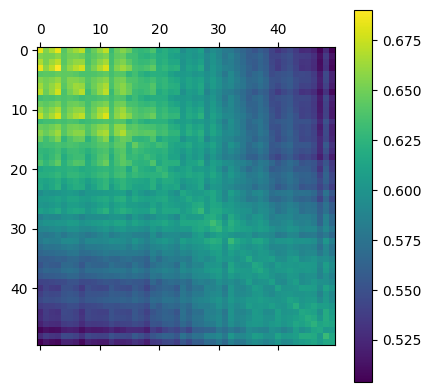

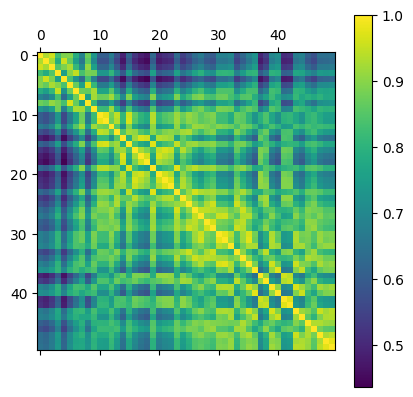

In [143]:
plt.matshow(torch.min(emp_cov_z,torch.ones(emp_cov_z.shape))[:50,:50])
plt.colorbar()
plt.show()
plt.matshow(estimated_cov.detach().numpy()[:50,:50])
plt.colorbar()
plt.show()

# Final one

In [ ]:
subset_num_days = 30
subset_num_locs = 200

fixed_moise_sims = norm.sample((num_days,fake_cov.shape[0])).to(dtype=torch.float64)


###
# Optimisation
###

fixed_noise = fixed_moise_sims[:,:200]#norm.sample((2000,fake_data.shape[1])).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta_ = tt(50.,requires_grad=True)
a_ = tt(0.1,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta_, a_], lr=0.02)
# comparing on the copula u-space
for epoch in range(5000):
    optimizer.zero_grad()
    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),
    a_*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)])
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # construct current guess of the covariance matrix
    est_cov = torch_Matern_05(est_dist_matrix, theta_)
    # sample from the current guess of the covariance matrix using Cholesky decomposition
    chol_cov = torch.linalg.cholesky(est_cov)
    #sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
    sims_z = sample_Gauss_fixed_noise( norm.sample((num_days,fake_cov.shape[0])).to(dtype=torch.float64) , chol_cov)  # to leverage SGD to combat bias
    #sims_u = norm.cdf(sims_z) # convert to U-space
    SR = tt(0.)
    sims_z_cens = torch.zeros((fake_data.shape[0], sims_z.shape[0], sims_z.shape[1]))
    for day in (range(fake_data.shape[0])):
        sims_z_cens[day] = torch.maximum(sims_z, censor_levels_u[day])
        SR += Energy_Score(0.5, fake_data_censored[day], sims_z_cens[day].T)
    SR.backward(retain_graph=True)
    optimizer.step()
    if epoch % 40 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {SR.item()}, Theta Gradient = {theta_.grad.item()}, Theta = {theta_.item()}, a Gradient = {a_.grad.item()}, a = {a_.item()}')

print(fake_theta, theta_,fake_a_, a_)